In [3]:
!pip install pymoo arabic_reshaper python_bidi

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 292.1/292.1 kB 13.2 MB/s eta 0:00:00


# فراخوانی کتابخانه های مورد نیاز

In [ ]:
import os, math, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
#import json
from matplotlib import font_manager as fm
from arabic_reshaper import reshape
from bidi.algorithm import get_display

from pymoo.core.problem import Problem
from pymoo.algorithms.moo.nsga2 import NSGA2
from pymoo.optimize import minimize
from pymoo.operators.sampling.rnd import FloatRandomSampling
from pymoo.operators.crossover.sbx import SBX
from pymoo.operators.mutation.pm import PM

warnings.filterwarnings("ignore", category=RuntimeWarning)

# تعیین ورودی

In [ ]:
INPUT_FILE = 'ks_wells.txt'
OUTPUT_DIR = 'ks_well_results'
os.makedirs(OUTPUT_DIR, exist_ok=True)

# تنظیمات فارسی نویسی
plt.rcParams["font.family"] = 'Adobe Arabic'
plt.rcParams["axes.unicode_minus"] = False
plt.rcParams['font.size'] = 16

# هزینه های پایه
PIPE_OIL_COST_PER_KM = 500.0
PIPE_GAS_COST_PER_KM = 800.0

# CAPEX پایه برای تاسیسات
OIL_BASE, OIL_ALPHA = 800_000.0, 180.0
GAS_BASE, GAS_BETA = 1_000_000.0, 150.0
COMBO_BASE, COMBO_GAMMA = 1_500_000.0, 160.0

EARTH_RADIUS_KM = 6371.0

N_GEN = 100
POP_SIZE = 100
MAX_FACILITIES = 15
MAX_BUDGET = 500_000_000.0

#  تعریف توابع کمکی

In [ ]:
def haversine_km(lat1, lon1, lat2, lon2):
    lat1, lon1, lat2, lon2 = map(np.radians, [lat1, lon1, lat2, lon2])
    dlat = lat2 - lat1
    dlon = lon2 - lon1
    a = np.sin(dlat/2.0)**2 + np.cos(lat1)*np.cos(lat2)*np.sin(dlon/2.0)**2
    a = np.clip(a, 0.0, 1.0)
    return EARTH_RADIUS_KM * 2.0 * np.arcsin(np.sqrt(a))

def persian_text(text):
    """تبدیل متن فارسی برای نمایش در نمودارها"""
    reshaped_text = reshape(text)
    return get_display(reshaped_text)

#  بارگذاری و پیش پردازش داده

In [ ]:
df = pd.read_csv(INPUT_FILE, quotechar='"')

# نگهداشتن ستونهای موردنیاز
cols_to_keep = ['KID', 'LATITUDE', 'LONGITUDE', 'IP_OIL', 'IP_GAS', 'IP_WATER']
df = df[[c for c in cols_to_keep if c in df.columns]]

# تبدیل به عدد
for col in ['LATITUDE', 'LONGITUDE']:
    df[col] = pd.to_numeric(df[col], errors='coerce').astype(np.float64)
for col in ['IP_OIL', 'IP_GAS', 'IP_WATER']:
    if col in df.columns:
        df[col] = pd.to_numeric(df[col], errors='coerce').fillna(0.0).astype(np.float64)
    else:
        df[col] = 0.0

# حذف داده های نامعتبر
df = df.dropna(subset=['LATITUDE', 'LONGITUDE'])
df = df[(df['LATITUDE'] != 0) & (df['LONGITUDE'] != 0)]

# نمونه گیری تصادفی از چاه ها برای کاهش حجم داده ها در سیستم های محاسباتی ضعیف
if len(df) > 5000:
    df = df.sample(n=5000, random_state=42)

df

,KID,LATITUDE,LONGITUDE,IP_OIL,IP_GAS,IP_WATER
148316,1006061802,39.554204,-99.705772,0.0,0.0,0.0
317514,1031431811,39.891649,-99.414278,0.0,0.0,0.0
264671,1026516561,37.855085,-95.431407,0.0,0.0,0.0
258072,1025811820,38.118048,-95.639223,0.0,0.0,0.0
194568,1006154917,37.526130,-101.680819,0.0,0.0,0.0
...,...,...,...,...,...,...
401535,1043127519,39.230679,-99.535222,0.0,0.0,0.0
78555,1002918136,37.990896,-96.103630,0.0,0.0,0.0
42715,1002878924,38.109230,-96.883790,0.0,0.0,0.0
144802,1006054915,37.894901,-99.710279,0.0,0.0,0.0


In [ ]:
# شناسایی نوع چاه بر اساس سیال غالب
df['TOTAL_FLUID'] = df['IP_OIL'] + df['IP_GAS'] + df['IP_WATER']
df['OIL_RATIO'] = df['IP_OIL'] / df['TOTAL_FLUID'].replace(0, 1)
df['GAS_RATIO'] = df['IP_GAS'] / df['TOTAL_FLUID'].replace(0, 1)
df['WATER_RATIO'] = df['IP_WATER'] / df['TOTAL_FLUID'].replace(0, 1)

def classify_well(row):
    if row['TOTAL_FLUID'] == 0:
        return 'Dry'
    ratios = [row['OIL_RATIO'], row['GAS_RATIO'], row['WATER_RATIO']]
    max_ratio = max(ratios)
    if max_ratio == row['OIL_RATIO']:
        return 'Oil'
    elif max_ratio == row['GAS_RATIO']:
        return 'Gas'
    else:
        return 'Water'

df['WELL_TYPE'] = df.apply(classify_well, axis=1)

# انتخاب چاه‌های فعال (دارای نفت، گاز یا آب)
active_wells = df[(df['IP_OIL'] > 0) | (df['IP_GAS'] > 0) | (df['IP_WATER'] > 0)]
print(f"تعداد چاه های فعال: {len(active_wells)}")

if len(active_wells) == 0:
    print("هیچ چاه فعالی یافت نشد!...")
    exit()

تعداد چاه های فعال: 521


#  ترسیم نمودار چاه های فعال با نوع سیال غالب

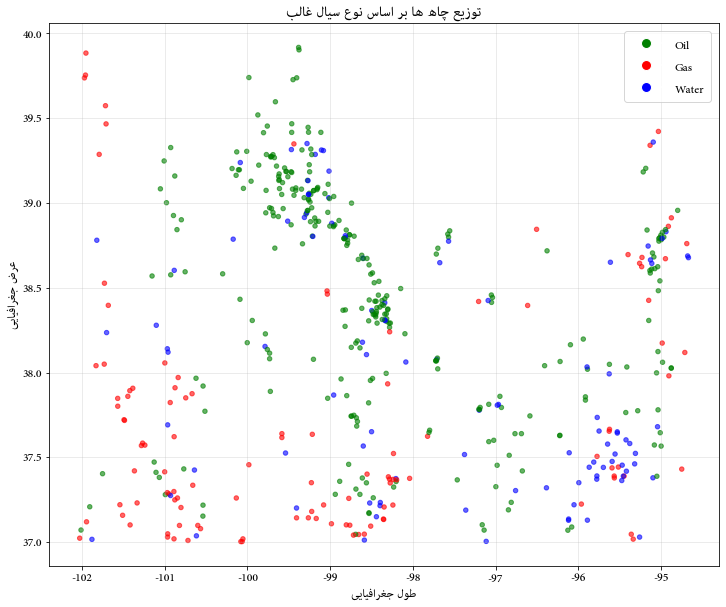

In [ ]:
plt.figure(figsize=(12, 10))

# ایجاد یک نموداررنگی مخصوص برای انواع چاه
colors = {'Oil': 'green', 'Gas': 'red', 'Water': 'blue'}
well_colors = [colors[t] for t in active_wells['WELL_TYPE']]

plt.scatter(active_wells['LONGITUDE'], active_wells['LATITUDE'],
            c=well_colors, s=20, alpha=0.6)

# افزودن legend
patches = [plt.Line2D([0], [0], marker='o', color='w', markerfacecolor=color,
                      markersize=10, label=persian_text(well_type))
           for well_type, color in colors.items()]
plt.legend(handles=patches)

plt.xlabel(persian_text('طول جغرافیایی'))
plt.ylabel(persian_text('عرض جغرافیایی'))
plt.title(persian_text('توزیع چاه ها بر اساس نوع سیال غالب'))
plt.grid(True, alpha=0.3)
plt.savefig(os.path.join(OUTPUT_DIR, 'well_distribution.png'), dpi=300, bbox_inches='tight')
plt.show()

#  خوشه بندی برای شناسایی مکان های بالقوه تاسیسات پلایشگاهی

In [ ]:
coords = active_wells[['LATITUDE', 'LONGITUDE']].values

# استفاده از KMeans برای خوشه بندی
kmeans = KMeans(n_clusters=min(MAX_FACILITIES, len(active_wells)), random_state=42, n_init=3)
kmeans.fit(coords)
cluster_centers = kmeans.cluster_centers_

In [ ]:
# انتخاب چاه های نزدیک به مراکز خوشه به عنوان کاندیدای تاسیسات
candidates_df = pd.DataFrame(columns=['lat', 'lon'])

for i, center in enumerate(cluster_centers):
    # پیدا کردن نزدیک‌ترین چاه به مرکز خوشه
    distances = np.sqrt((coords[:, 0] - center[0])**2 + (coords[:, 1] - center[1])**2)
    nearest_idx = np.argmin(distances)

    well = active_wells.iloc[nearest_idx]
    candidates_df.loc[i] = [well['LATITUDE'], well['LONGITUDE']]

candidates_df.to_csv(os.path.join(OUTPUT_DIR, 'candidates.csv'), index=False)
K = len(candidates_df)
print(f"تعداد کاندیداهای تاسیسات پالایشگاهی: {K}")

تعداد کاندیداهای تاسیسات پالایشگاهی: 15


In [ ]:
# ---------- محاسبه ماتریس فاصله ----------
wells_coords = active_wells[['LATITUDE', 'LONGITUDE']].values
wells_oil = active_wells['IP_OIL'].values
wells_gas = active_wells['IP_GAS'].values
wells_kid = active_wells['KID'].values
wells_type = active_wells['WELL_TYPE'].values
cand_coords = candidates_df[['lat', 'lon']].values

# محاسبه ماتریس فاصله
dist_matrix = np.zeros((len(wells_coords), K))
for i in range(len(wells_coords)):
    for j in range(K):
        dist_matrix[i, j] = haversine_km(
            wells_coords[i, 0], wells_coords[i, 1],
            cand_coords[j, 0], cand_coords[j, 1]
        )

#  تعریف مسئله بهینه سازی
اهداف:

افزایش تولید کل نفت و گاز

کاهش هزینه

In [ ]:
class FacilityLocationProblem(Problem):
    def __init__(self):
        # سه متغیر برای هر تاسیسات: نوع (0-2)، انتخاب/عدم انتخاب (0-1) و ظرفیت (0-1)
        super().__init__(n_var=K * 3, n_obj=3, n_ieq_constr=1, xl=0.0, xu=1.0)
        self.history = []

    def _evaluate(self, x, out, *args, **kwargs):
        n_pop = x.shape[0]
        F = np.zeros((n_pop, 3))  # اهداف: هزینه، میانگین فاصله، تولید منفی
        G = np.zeros((n_pop, 1))  # قیود: بودجه

        solutions_info = []

        for idx in range(n_pop):
            sol = x[idx].reshape(K, 3)
            # نوع تاسیسات (ستون اول)
            facility_types = np.floor(sol[:, 0] * 2.999).astype(int)  # 0, 1, 2
            # انتخاب/عدم انتخاب تاسیسات (ستون دوم)
            facility_selected = sol[:, 1] > 0.5
            # سطح ظرفیت تاسیسات (ستون سوم)
            capacity_levels = sol[:, 2]  # 0-1

            capex, pipe_cost = 0.0, 0.0
            total_oil, total_gas = 0.0, 0.0
            distances = []

            # ذخیره اطلاعات اتصال چاه ها
            well_assignments = [[] for _ in range(K)]

            # محاسبه انتساب چاه ها به تاسیسات
            for iw in range(len(wells_coords)):
                min_cost = float('inf')
                best_j = -1

                # محاسبه هزینه برای نفت
                oil_production = wells_oil[iw]
                if oil_production > 0:
                    for j in range(K):
                        if facility_selected[j] and facility_types[j] in [0, 2]:
                            d = dist_matrix[iw, j]
                            cost = PIPE_OIL_COST_PER_KM * d
                            # در نظر گیری سطح ظرفیت در هزینه
                            cost *= (1 + capacity_levels[j] * 0.5)
                            if cost < min_cost:
                                min_cost, best_j = cost, j

                    if best_j != -1:
                        # در نظر گیری سطح ظرفیت در تولید
                        production_factor = 0.5 + capacity_levels[best_j] * 0.5
                        actual_production = oil_production * production_factor

                        pipe_cost += min_cost
                        total_oil += actual_production
                        distances.append(d)
                        well_assignments[best_j].append({
                            'well_id': int(wells_kid[iw]),
                            'well_type': wells_type[iw],
                            'production': actual_production,
                            'distance': d,
                            'fluid_type': 'oil'
                        })

                # محاسبه هزینه برای گاز
                gas_production = wells_gas[iw]
                if gas_production > 0:
                    min_cost = float('inf')
                    best_j = -1
                    for j in range(K):
                        if facility_selected[j] and facility_types[j] in [1, 2]:
                            d = dist_matrix[iw, j]
                            cost = PIPE_GAS_COST_PER_KM * d
                            # در نظر گیری سطح ظرفیت در هزینه
                            cost *= (1 + capacity_levels[j] * 0.5)
                            if cost < min_cost:
                                min_cost, best_j = cost, j

                    if best_j != -1:
                        # در نظر گیری سطح ظرفیت در تولید
                        production_factor = 0.5 + capacity_levels[best_j] * 0.5
                        actual_production = gas_production * production_factor

                        pipe_cost += min_cost
                        total_gas += actual_production
                        distances.append(d)
                        well_assignments[best_j].append({
                            'well_id': int(wells_kid[iw]),
                            'well_type': wells_type[iw],
                            'production': actual_production,
                            'distance': d,
                            'fluid_type': 'gas'
                        })

            # محاسبه CAPEX برای تاسیسات انتخاب شده
            for j in range(K):
                if facility_selected[j]:
                    base_cost = 0
                    if facility_types[j] == 0:  # نفتی
                        base_cost = OIL_BASE
                        capacity_cost = OIL_ALPHA * (10000 * capacity_levels[j])
                    elif facility_types[j] == 1:  # گازی
                        base_cost = GAS_BASE
                        capacity_cost = GAS_BETA * (20000 * capacity_levels[j])
                    elif facility_types[j] == 2:  # ترکیبی
                        base_cost = COMBO_BASE
                        capacity_cost = COMBO_GAMMA * (30000 * capacity_levels[j])

                    capex += base_cost + capacity_cost

            total_cost = capex + pipe_cost
            avg_distance = np.mean(distances) if distances else 0
            total_production = total_oil + total_gas

            F[idx, :] = [total_cost, avg_distance, -total_production]
            G[idx, 0] = total_cost - MAX_BUDGET

            # ذخیره اطلاعات راه حل
            solutions_info.append({
                'well_assignments': well_assignments,
                'facility_selected': facility_selected.copy(),
                'facility_types': facility_types.copy(),
                'capacity_levels': capacity_levels.copy(),
                'total_oil': total_oil,
                'total_gas': total_gas
            })

        out["F"] = F
        out["G"] = G
        self.history.append(solutions_info)

#  اجرای بهینه سازی

In [ ]:
print("شروع بهینه سازی چندهدفه...")
problem = FacilityLocationProblem()

# استفاده از نمونه گیری متنوع تر
class DiverseSampling(FloatRandomSampling):
    def _do(self, problem, n_samples, **kwargs):
        x = np.random.random((n_samples, problem.n_var))

        # ایجاد تنوع در نمونه های اولیه
        for i in range(n_samples):
            # برخی تاسیسات را فعال کنید
            for j in range(K):
                if np.random.random() > 0.7:  # 30% احتمال فعال بودن
                    x[i, j*3+1] = 1.0

                # انواع مختلف تاسیسات
                x[i, j*3] = np.random.choice([0.1, 0.5, 0.9])  # انواع مختلف

                # سطوح مختلف ظرفیت
                x[i, j*3+2] = np.random.random()  # ظرفیت های مختلف
        return x

algorithm = NSGA2(
    pop_size=POP_SIZE,
    sampling=DiverseSampling(),
    crossover=SBX(prob=0.9, eta=15),
    mutation=PM(eta=20),
    eliminate_duplicates=True
)

res = minimize(problem, algorithm, ('n_gen', N_GEN), seed=42, verbose=True)

شروع بهینه سازی چندهدفه...

Compiled modules for significant speedup can not be used!
https://pymoo.org/installation.html#installation

To disable this warning:
from pymoo.config import Config
Config.warnings['not_compiled'] = False

n_gen  |  n_eval  | n_nds  |     cv_min    |     cv_avg    |      eps      |   indicator  
     1 |      100 |     16 |  0.000000E+00 |  0.000000E+00 |             - |             -
     2 |      200 |     17 |  0.000000E+00 |  0.000000E+00 |  0.1907172514 |         ideal
     3 |      300 |     25 |  0.000000E+00 |  0.000000E+00 |  0.0779276782 |         ideal
     4 |      400 |     34 |  0.000000E+00 |  0.000000E+00 |  0.0070082768 |         ideal
     5 |      500 |     45 |  0.000000E+00 |  0.000000E+00 |  0.1970117641 |         nadir
     6 |      600 |     52 |  0.000000E+00 |  0.000000E+00 |  0.3521944730 |         ideal
     7 |      700 |     53 |  0.000000E+00 |  0.000000E+00 |  0.1585069558 |         ideal
     8 |      800 |     55 |  0.000000

    86 |     8600 |    100 |  0.000000E+00 |  0.000000E+00 |  0.0051919816 |             f
    87 |     8700 |    100 |  0.000000E+00 |  0.000000E+00 |  0.0014276793 |             f
    88 |     8800 |    100 |  0.000000E+00 |  0.000000E+00 |  0.0025709234 |             f
    89 |     8900 |    100 |  0.000000E+00 |  0.000000E+00 |  0.0011346051 |             f
    90 |     9000 |    100 |  0.000000E+00 |  0.000000E+00 |  0.0027138496 |             f
    91 |     9100 |    100 |  0.000000E+00 |  0.000000E+00 |  0.0015959214 |             f
    92 |     9200 |    100 |  0.000000E+00 |  0.000000E+00 |  0.0029584230 |             f
    93 |     9300 |    100 |  0.000000E+00 |  0.000000E+00 |  0.0013398875 |             f
    94 |     9400 |    100 |  0.000000E+00 |  0.000000E+00 |  0.0027495277 |             f
    95 |     9500 |    100 |  0.000000E+00 |  0.000000E+00 |  0.0019264273 |             f
    96 |     9600 |    100 |  0.000000E+00 |  0.000000E+00 |  0.0041184225 |             f

#  پردازش و ذخیره نتایج

In [ ]:
# فیلتر کردن راه حل های معتبر
valid_mask = ~np.any(np.isinf(res.F), axis=1) & ~np.any(np.isnan(res.F), axis=1)
valid_F = res.F[valid_mask]
valid_X = res.X[valid_mask]

if len(valid_F) == 0:
    print("هیچ راه حل معتبری یافت نشد! ایجاد راه حل های نمونه...")
    # ایجاد راه حل های متنوع نمونه
    valid_F = []
    for i in range(10):
        cost = 10_000_000 * (i + 1)
        production = 500_000 * (i + 1)
        distance = 5.0 - i * 0.3
        valid_F.append([cost, distance, -production])
    valid_F = np.array(valid_F)

solutions_df = pd.DataFrame({
    "cost": valid_F[:, 0],
    "avg_distance": valid_F[:, 1],
    "total_production": -valid_F[:, 2]
})

solutions_df.to_csv(os.path.join(OUTPUT_DIR, 'pareto_solutions.csv'), index=False)
print("راه حل های یافت شده:", len(solutions_df))
solutions_df

راه حل های یافت شده: 100


,cost,avg_distance,total_production
0,0.000000e+00,0.000000,0.000000e+00
1,0.000000e+00,0.000000,0.000000e+00
2,2.070988e+07,324.591322,2.607411e+06
3,9.848019e+07,190.363820,2.985044e+06
4,9.848019e+07,190.363820,2.985044e+06
...,...,...,...
95,1.422599e+07,232.176164,1.929577e+06
96,3.551011e+07,167.087325,2.620418e+06
97,2.115885e+07,187.458707,1.854325e+05
98,1.488248e+07,203.589103,1.844246e+06


# ترسیم نمودارها

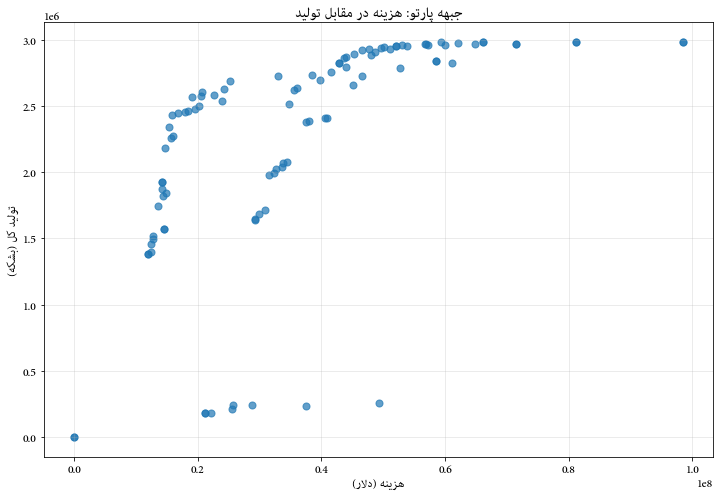

In [ ]:
# ---------- نمودار جبهه پارتو نهایی ----------
plt.figure(figsize=(12, 8))
plt.scatter(solutions_df['cost'], solutions_df['total_production'], alpha=0.7, s=50)
plt.xlabel(persian_text('هزینه (دلار)'))
plt.ylabel(persian_text('تولید کل (بشکه)'))
plt.title(persian_text('جبهه پارتو: هزینه در مقابل تولید'))
plt.grid(True, alpha=0.3)
plt.savefig(os.path.join(OUTPUT_DIR, 'pareto_front.png'), dpi=300, bbox_inches='tight')
plt.show()

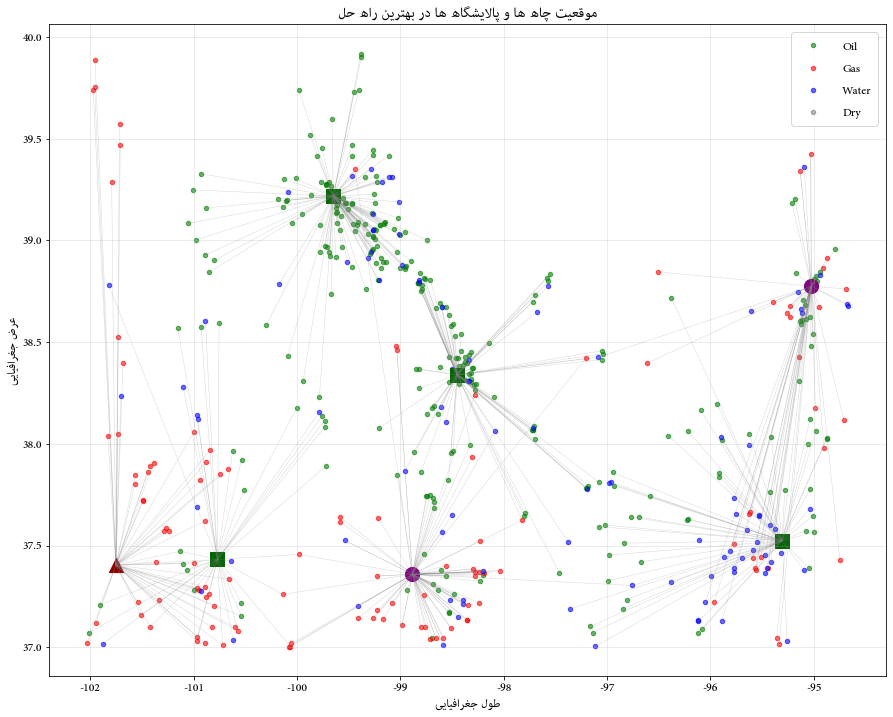

In [ ]:
# ---------- نمایش یک راه حل بهینه ----------

# انتخاب راه حل با بهترین کارایی (تولید به ازای هزینه)
if len(solutions_df) > 0:
    solutions_df['efficiency'] = solutions_df['total_production'] / solutions_df['cost']
    best_sol_idx = solutions_df['efficiency'].idxmax() # راه حل با بیشترین بهره وری

    if best_sol_idx < len(problem.history[-1]):
        best_sol_info = problem.history[-1][best_sol_idx]

        # رسم نمودار موقعیت چاه ها و پالایشگاه ها
        plt.figure(figsize=(15, 12))

        # رسم چاه ها بر اساس نوع سیال
        colors = {'Oil': 'green', 'Gas': 'red', 'Water': 'blue', 'Dry': 'gray'}
        for well_type, color in colors.items():
            mask = active_wells['WELL_TYPE'] == well_type
            plt.scatter(active_wells.loc[mask, 'LONGITUDE'],
                       active_wells.loc[mask, 'LATITUDE'],
                       c=color, s=20, alpha=0.6, label=persian_text(well_type))

        # رسم پالایشگاه های انتخاب شده و اتصالات
        facility_colors = {0: 'darkgreen', 1: 'darkred', 2: 'purple'}
        facility_labels = {0: 'نفتی', 1: 'گازی', 2: 'ترکیبی'}
        facility_markers = {0: 's', 1: '^', 2: 'o'}

        for j in range(K):
            if best_sol_info['facility_selected'][j]:
                # رسم پالایشگاه
                plt.scatter(candidates_df.iloc[j]['lon'],
                           candidates_df.iloc[j]['lat'],
                           c=facility_colors[best_sol_info['facility_types'][j]],
                           marker=facility_markers[best_sol_info['facility_types'][j]],
                           s=200,
                           label=persian_text(facility_labels[best_sol_info['facility_types'][j]]) if j == 0 else "")

                # رسم اتصالات به چاه ها
                for well in best_sol_info['well_assignments'][j]:
                    well_idx = np.where(wells_kid == well['well_id'])[0]
                    if len(well_idx) > 0:
                        well_idx = well_idx[0]
                        plt.plot([candidates_df.iloc[j]['lon'], wells_coords[well_idx, 1]],
                                [candidates_df.iloc[j]['lat'], wells_coords[well_idx, 0]],
                                'gray', alpha=0.3, linewidth=0.5)

        plt.xlabel(persian_text('طول جغرافیایی'))
        plt.ylabel(persian_text('عرض جغرافیایی'))
        plt.title(persian_text('موقعیت چاه ها و پالایشگاه ها در بهترین راه حل'))
        plt.legend()
        plt.grid(True, alpha=0.3)
        plt.savefig(os.path.join(OUTPUT_DIR, 'best_solution_map_best.png'), dpi=300, bbox_inches='tight')
        plt.show()

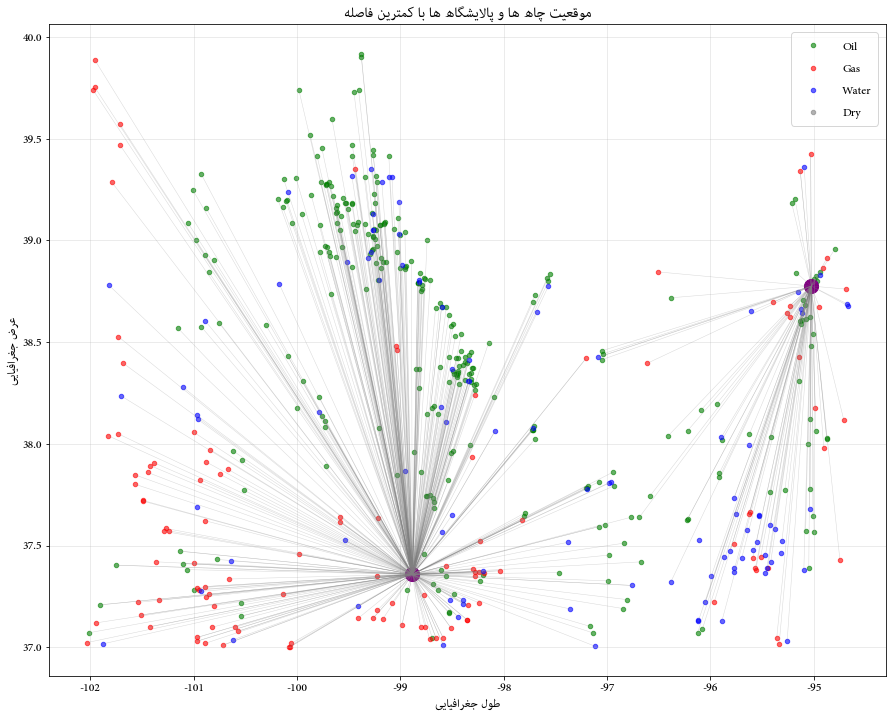

In [ ]:
# انتخاب راه حل با کمترین فاصله
if len(solutions_df) > 0:
    best_sol_idx = solutions_df['avg_distance'].idxmin() # راه حل با کمترین فاصله

    if best_sol_idx < len(problem.history[-1]):
        best_sol_info = problem.history[-1][best_sol_idx]

        # رسم نمودار موقعیت چاه ها و پالایشگاه ها
        plt.figure(figsize=(15, 12))

        # رسم چاه ها بر اساس نوع سیال
        colors = {'Oil': 'green', 'Gas': 'red', 'Water': 'blue', 'Dry': 'gray'}
        for well_type, color in colors.items():
            mask = active_wells['WELL_TYPE'] == well_type
            plt.scatter(active_wells.loc[mask, 'LONGITUDE'],
                       active_wells.loc[mask, 'LATITUDE'],
                       c=color, s=20, alpha=0.6, label=persian_text(well_type))

        # رسم پالایشگاه های انتخاب شده و اتصالات
        facility_colors = {0: 'darkgreen', 1: 'darkred', 2: 'purple'}
        facility_labels = {0: 'نفتی', 1: 'گازی', 2: 'ترکیبی'}
        facility_markers = {0: 's', 1: '^', 2: 'o'}

        for j in range(K):
            if best_sol_info['facility_selected'][j]:
                # رسم پالایشگاه
                plt.scatter(candidates_df.iloc[j]['lon'],
                           candidates_df.iloc[j]['lat'],
                           c=facility_colors[best_sol_info['facility_types'][j]],
                           marker=facility_markers[best_sol_info['facility_types'][j]],
                           s=200,
                           label=persian_text(facility_labels[best_sol_info['facility_types'][j]]) if j == 0 else "")

                # رسم اتصالات به چاه ها
                for well in best_sol_info['well_assignments'][j]:
                    well_idx = np.where(wells_kid == well['well_id'])[0]
                    if len(well_idx) > 0:
                        well_idx = well_idx[0]
                        plt.plot([candidates_df.iloc[j]['lon'], wells_coords[well_idx, 1]],
                                [candidates_df.iloc[j]['lat'], wells_coords[well_idx, 0]],
                                'gray', alpha=0.3, linewidth=0.5)

        plt.xlabel(persian_text('طول جغرافیایی'))
        plt.ylabel(persian_text('عرض جغرافیایی'))
        plt.title(persian_text('موقعیت چاه ها و پالایشگاه ها با کمترین فاصله'))
        plt.legend()
        plt.grid(True, alpha=0.3)
        plt.savefig(os.path.join(OUTPUT_DIR, 'best_solution_map_distance.png'), dpi=300, bbox_inches='tight')
        plt.show()

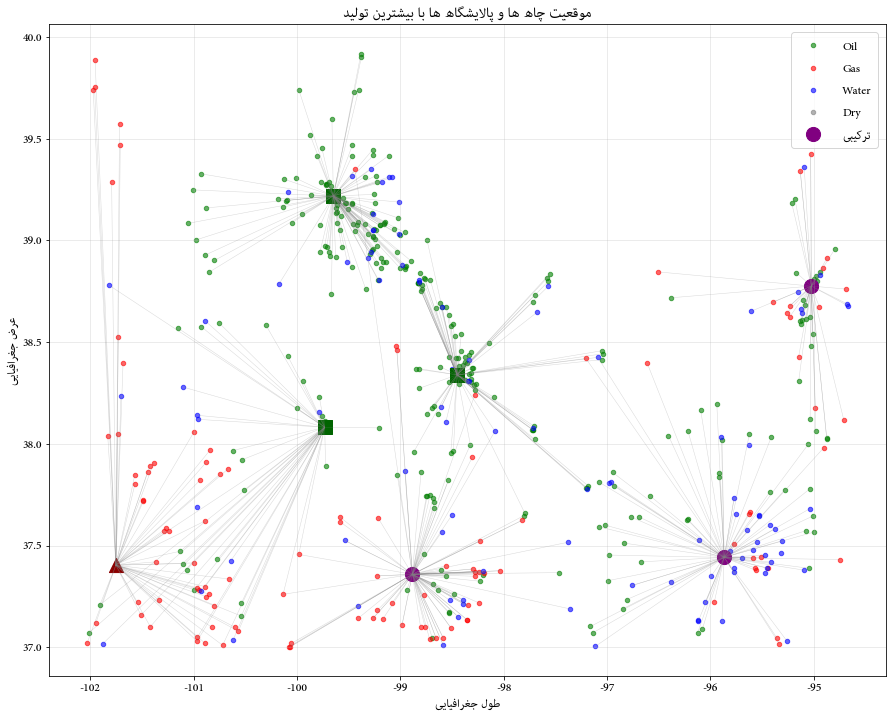

In [ ]:
# انتخاب راه حل با بیشترین تولید
if len(solutions_df) > 0:
    best_sol_idx = solutions_df['total_production'].idxmax() # راه حل با بیشترین تولید

    if best_sol_idx < len(problem.history[-1]):
        best_sol_info = problem.history[-1][best_sol_idx]

        # رسم نمودار موقعیت چاه ها و پالایشگاه ها
        plt.figure(figsize=(15, 12))

        # رسم چاه ها بر اساس نوع سیال
        colors = {'Oil': 'green', 'Gas': 'red', 'Water': 'blue', 'Dry': 'gray'}
        for well_type, color in colors.items():
            mask = active_wells['WELL_TYPE'] == well_type
            plt.scatter(active_wells.loc[mask, 'LONGITUDE'],
                       active_wells.loc[mask, 'LATITUDE'],
                       c=color, s=20, alpha=0.6, label=persian_text(well_type))

        # رسم پالایشگاه های انتخاب شده و اتصالات
        facility_colors = {0: 'darkgreen', 1: 'darkred', 2: 'purple'}
        facility_labels = {0: 'نفتی', 1: 'گازی', 2: 'ترکیبی'}
        facility_markers = {0: 's', 1: '^', 2: 'o'}

        for j in range(K):
            if best_sol_info['facility_selected'][j]:
                # رسم پالایشگاه
                plt.scatter(candidates_df.iloc[j]['lon'],
                           candidates_df.iloc[j]['lat'],
                           c=facility_colors[best_sol_info['facility_types'][j]],
                           marker=facility_markers[best_sol_info['facility_types'][j]],
                           s=200,
                           label=persian_text(facility_labels[best_sol_info['facility_types'][j]]) if j == 0 else "")

                # رسم اتصالات به چاه ها
                for well in best_sol_info['well_assignments'][j]:
                    well_idx = np.where(wells_kid == well['well_id'])[0]
                    if len(well_idx) > 0:
                        well_idx = well_idx[0]
                        plt.plot([candidates_df.iloc[j]['lon'], wells_coords[well_idx, 1]],
                                [candidates_df.iloc[j]['lat'], wells_coords[well_idx, 0]],
                                'gray', alpha=0.3, linewidth=0.5)

        plt.xlabel(persian_text('طول جغرافیایی'))
        plt.ylabel(persian_text('عرض جغرافیایی'))
        plt.title(persian_text('موقعیت چاه ها و پالایشگاه ها با بیشترین تولید'))
        plt.legend()
        plt.grid(True, alpha=0.3)
        plt.savefig(os.path.join(OUTPUT_DIR, 'best_solution_map_product.png'), dpi=300, bbox_inches='tight')
        plt.show()